In [ ]:
!pip install pywavelets
import timeit, pywt
import numpy as np
import scipy.io as spio
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 43.5 MB/s eta 0:00:00


In [ ]:
# Import OS libraries
import os
import itertools

# Data handling tools
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm import tqdm
import cv2
import os
import imutils
import tensorflow as tf
import keras

In [ ]:
!pip install Pillow

In [ ]:
from glob import glob
from tensorflow.keras.models import Model

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix , classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense,  BatchNormalization, Activation, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam , Adamax
from tensorflow.keras import regularizers
from tensorflow.keras.layers import Dense

In [ ]:
from google.colab import files
from io import BytesIO
# Display images.
from IPython.display import display
from PIL import ImageEnhance
from PIL import Image

In [ ]:
from google.colab import drive


In [ ]:
import seaborn as sns

In [ ]:
drive.mount('/content/drive/')

Mounted at /content/drive/


In [ ]:
# read data from database
start_process = timeit.default_timer()
read_data_start = timeit.default_timer()
classes = [
    0,  # F
    1,  # N
    2,  # S
    3,  # V
    4,  # Q
]
classes_name = ["F", "N", "S", "V", "Q"]
data = []
input_length = 280
samples = spio.loadmat("/content/drive/MyDrive/Thesis Latest/mitbih_aami (2).mat")
samples = samples["s2s_mitbih"]
values = samples[0]["seg_values"]

labels = samples[0]["seg_labels"]
num_annots = sum([item.shape[0] for item in values])


In [ ]:
import numpy as np
import timeit
import scipy.io as spio
# Start timer
read_data_start = timeit.default_timer()

samples = spio.loadmat("/content/drive/MyDrive/Thesis Latest/mitbih_aami (2).mat")
samples = samples["s2s_mitbih"]
values = samples[0]["seg_values"] # redefine values
labels = samples[0]["seg_labels"]
num_annots = sum([item.shape[0] for item in values])

# Error Handling: Check if values and labels exist and are non-empty
if values.size == 0 or labels.size == 0:
    raise ValueError("The values or labels arrays are empty or missing.")

# Aggregate segments (beats) with interpolation
data = []
try:
    for item in values:
        if len(data) >= num_annots:
            break
        # Check if item[0] is a nested array or not, process accordingly
        if isinstance(item[0], np.ndarray):
            # Vectorized interpolation using numpy
            interpolated_segments = np.array([np.interp(itm[0], (itm[0].min(), itm[0].max()), (0, 1)) for itm in item])
            data.extend(interpolated_segments)
        else:
            raise ValueError("Expected item[0] to be a numpy array.")
except Exception as e:
    raise ValueError(f"Error processing values: {e}")

# Aggregate and normalize labels
label_map = {"F": 0, "N": 1, "S": 2, "V": 3, "Q": 4}

# Check if labels contain the right structure
try:
    t_labels = [str(label) for sublist in labels[:num_annots] for label in sublist[0]]  # Flatten labels
except (IndexError, TypeError) as e:
    raise ValueError(f"Error processing labels: {e}")

# Vectorized label normalization using numpy
t_labels_np = np.array(t_labels)
n_labels = np.vectorize(label_map.get)(t_labels_np)

# Remove invalid labels (those mapped to None)
valid_labels_mask = np.isin(n_labels, list(label_map.values()))  # Filter valid labels
n_labels = n_labels[valid_labels_mask]

# Reshape data to (-1, 280), limit to num_annots annotations
try:
    data = np.reshape(data[:num_annots * 280], (-1, 280))
except ValueError as e:
    raise ValueError(f"Error reshaping data: {e}")

# Convert normalized labels to numpy array
annotation = np.asarray(n_labels[:num_annots])

# End timer and print duration
read_data_end = timeit.default_timer()
print(f"read data duration: {read_data_end - read_data_start:.2f} seconds")

# Class details function to count occurrences of each class
def class_details(labels, classes):
    details = np.zeros(len(classes), dtype=int)
    for l in labels:
        if l in classes:
            details[l] += 1
    return details

# Get class details for the normalized labels
classes = [0, 1, 2, 3, 4]  # Corresponding to F, N, S, V, Q
classes_name = ["F", "N", "S", "V", "Q"]
details = class_details(annotation, classes)

# Print class counts
for i, v in enumerate(classes):
    print(f"{classes_name[i]:^5} : {details[i]:^5}")

read data duration: 3.54 seconds
  F   :  802 
  N   : 90502
  S   : 2777 
  V   : 7226 
  Q   : 8031 


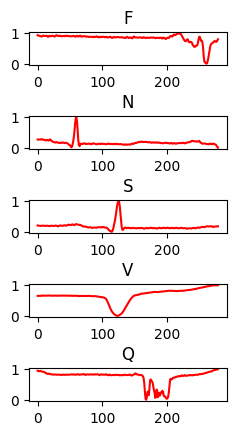

In [ ]:
 import matplotlib.pyplot as plt
 for i,j in enumerate([17814,0,6,1905,3168]):
      i+=1
      plt.subplot(5,2,(2*i)-1)
      plt.subplots_adjust(wspace=0.5, hspace=1.5)
      plt.title(classes_name[annotation[j]])
      plt.plot(data[j],'r')

In [ ]:
import pywt
import timeit
import numpy as np

# Start the timer for wavelet transform
wt_start = timeit.default_timer()
print("Wavelet transform process...")

# Discrete Wavelet Transform (DWT) with a better wavelet filter like 'sym5' or 'coif5'
data1, data2 = pywt.dwt(data, "sym5")
data = data1

wt_end = timeit.default_timer()
print("Done")
print("Wavelet transform duration : {} seconds".format(wt_end - wt_start))

# Input length for reshaping and model compatibility
input_length = np.shape(data2)[1]
print("Input shape {}".format(input_length))
print("data1 shape: {}".format(np.shape(data1)))
print("data2 shape: {}".format(np.shape(data2)))




Wavelet transform process...
Done
Wavelet transform duration : 0.38637840300000903 seconds
Input shape 144
data1 shape: (109338, 144)
data2 shape: (109338, 144)


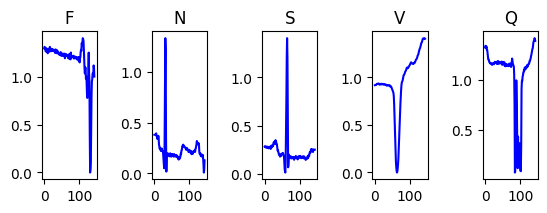

In [ ]:
for d in data:
    d = np.reshape(d,(input_length,1))

for i,j in enumerate([17814,0,6,1905,3168]):
    plt.subplot(2,5,i+6)
    plt.subplots_adjust(wspace=1, hspace=0.5)
    plt.title(classes_name[annotation[j]])
    plt.plot(data[j],'b')
plt.show()

exit(1)

In [ ]:
data.shape


(109338, 144)

In [ ]:
annotation.shape

(109338,)

In [ ]:
# split data to train and test 9-1 ...
print("split data to train and test 9-1 ...")
from sklearn.model_selection import train_test_split

inter_x_train, inter_x_test, inter_y_train, inter_y_test = train_test_split(
    data, annotation, test_size=0.1, train_size=0.9, shuffle=True
)
print("train data")
details = class_details(inter_y_train, classes)
for i, v in enumerate(classes):
    print("{:^5} : {:^5}".format(classes_name[i], details[i]))

print("test data")
details = class_details(inter_y_test, classes)
for i, v in enumerate(classes):
    print("{:^5} : {:^5}".format(classes_name[i], details[i]))

split data to train and test 9-1 ...
train data
  F   :  740 
  N   : 81560
  S   : 2474 
  V   : 6459 
  Q   : 7171 
test data
  F   :  62  
  N   : 8942 
  S   :  303 
  V   :  767 
  Q   :  860 


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
import numpy as np
import scipy.io



# Define the generator model
def build_generator(noise_dim, output_dim):
    model = tf.keras.Sequential()
    model.add(layers.Dense(256, activation='relu', input_dim=noise_dim))
    model.add(layers.BatchNormalization())
    model.add(layers.Dense(512, activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Dense(1024, activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Dense(output_dim, activation='tanh'))
    return model

# Define the discriminator model
def build_discriminator(input_dim):
    model = tf.keras.Sequential()
    model.add(layers.Dense(1024, activation='relu', input_dim=input_dim))
    model.add(layers.Dropout(0.3))
    model.add(layers.Dense(512, activation='relu'))
    model.add(layers.Dropout(0.3))
    model.add(layers.Dense(256, activation='relu'))
    model.add(layers.Dropout(0.3))
    model.add(layers.Dense(1, activation='sigmoid'))
    return model

# Step 2: Define GAN model combining generator and discriminator
class GAN(tf.keras.Model):
    def __init__(self, generator, discriminator, **kwargs):
        super(GAN, self).__init__(**kwargs)
        self.generator = generator
        self.discriminator = discriminator
        self.d_optimizer = tf.keras.optimizers.Adam(learning_rate=0.0002) # Initialize d_optimizer here
        self.g_optimizer = tf.keras.optimizers.Adam(learning_rate=0.0002) # Initialize g_optimizer here

    def train_step(self, real_data):
        batch_size = tf.shape(real_data)[0]
        noise = tf.random.normal(shape=(batch_size, noise_dim))

        # Train the discriminator
        with tf.GradientTape() as tape:
            generated_data = self.generator(noise)
            real_output = self.discriminator(real_data)
            fake_output = self.discriminator(generated_data)
            d_loss = self.loss(tf.ones_like(real_output), real_output) + self.loss(tf.zeros_like(fake_output), fake_output)

        grads = tape.gradient(d_loss, self.discriminator.trainable_variables)
        self.d_optimizer.apply_gradients(zip(grads, self.discriminator.trainable_variables))

        # Train the generator
        with tf.GradientTape() as tape:
            generated_data = self.generator(noise)
            fake_output = self.discriminator(generated_data)
            g_loss = self.loss(tf.ones_like(fake_output), fake_output)

        grads = tape.gradient(g_loss, self.generator.trainable_variables)
        self.g_optimizer.apply_gradients(zip(grads, self.generator.trainable_variables))

        return {"d_loss": d_loss, "g_loss": g_loss}

# Step 3: Training the GAN model
noise_dim = 100
output_dim = inter_x_train.shape[1]  # Use the number of features from the ECG data
generator = build_generator(noise_dim, output_dim)
discriminator = build_discriminator(output_dim)

gan = GAN(generator=generator, discriminator=discriminator)
gan.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0002), # Use a single optimizer for both generator and discriminator
    loss=tf.keras.losses.BinaryCrossentropy(),
)

# Train the GAN model
gan.fit(inter_x_train, epochs=25, batch_size=32)


Epoch 1/25
3076/3076 ━━━━━━━━━━━━━━━━━━━━ 24s 5ms/step - d_loss: 0.5582 - g_loss: 5.1983
Epoch 2/25
3076/3076 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - d_loss: 0.6032 - g_loss: 3.6795
Epoch 3/25
3076/3076 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - d_loss: 0.6802 - g_loss: 3.2910
Epoch 4/25
3076/3076 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - d_loss: 0.8251 - g_loss: 2.7240
Epoch 5/25
3076/3076 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - d_loss: 0.7509 - g_loss: 2.8065
Epoch 6/25
3076/3076 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - d_loss: 0.8030 - g_loss: 3.1482
Epoch 7/25
3076/3076 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - d_loss: 0.6940 - g_loss: 2.7550
Epoch 8/25
3076/3076 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - d_loss: 0.5767 - g_loss: 3.0906
Epoch 9/25
3076/3076 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - d_loss: 0.5558 - g_loss: 2.9514
Epoch 10/25
3076/3076 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - d_loss: 0.4807 - g_loss: 3.5791
Epoch 11/25
3076/3076 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - d_loss: 0.4966 - g_loss: 3.5831
Epoch 12/25
3076/307

In [ ]:
import numpy as np

def markov_chain_refinement(data, transition_matrix):
    # Refine each column (feature) of the data independently
    refined_data = []

    for i in range(data.shape[1]):  # Iterate through each column (feature)
        current_column = data[:, i]
        current_refined_column = []

        # Start with a random state for the Markov chain
        current_state = np.random.choice(len(transition_matrix))
        current_refined_column.append(current_column[current_state])

        for _ in range(1, len(current_column)):
            # Transition to the next state based on the current state
            next_state = np.random.choice(len(transition_matrix), p=transition_matrix[current_state])
            current_refined_column.append(current_column[next_state])
            current_state = next_state

        refined_data.append(current_refined_column)

    # Convert refined data back to a NumPy array
    refined_data = np.array(refined_data).T  # Transpose to match original shape

    return refined_data

def refine_synthetic_data_with_markov(gan_generated_data):
    print(f"Shape of gan_generated_data: {gan_generated_data.shape}")

    if len(gan_generated_data.shape) >= 2:

        incrementX = gan_generated_data[:, :144]
    else:

        incrementX = np.tile(gan_generated_data, (100, 144 // gan_generated_data.shape[0]))[:100, :144]

    # Define a simple transition matrix for Markov Chain (you can modify this)
    transition_matrix = np.array([[0.9, 0.1], [0.5, 0.5]])  # Example matrix

    # Refine each column independently using the Markov Chain
    refined_data = markov_chain_refinement(incrementX, transition_matrix)


    refined_data = refined_data[:100, :144]

    return refined_data
noise = tf.random.normal(shape=(100, noise_dim))
synthetic_data = gan.generator(noise)

gan_generated_data = synthetic_data.numpy()




refined_ecg_data = refine_synthetic_data_with_markov(gan_generated_data)

# Check the shape
print(f"Shape of refined_ecg_data: {refined_ecg_data.shape}")

Shape of gan_generated_data: (100, 144)
Shape of refined_ecg_data: (100, 144)


In [ ]:
inter_x_train.shape


(98404, 144)

In [ ]:
inter_x_train=np.vstack((inter_x_train,refined_ecg_data))

In [ ]:
inter_x_train.shape

(98504, 144)

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
import numpy as np
import scipy.io



# Define the generator model
def build_generator(noise_dim, output_dim):
    model = tf.keras.Sequential()
    model.add(layers.Dense(256, activation='relu', input_dim=noise_dim))
    model.add(layers.BatchNormalization())
    model.add(layers.Dense(512, activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Dense(1024, activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Dense(output_dim, activation='tanh'))
    return model

# Define the discriminator model
def build_discriminator(input_dim):
    model = tf.keras.Sequential()
    model.add(layers.Dense(1024, activation='relu', input_dim=input_dim))
    model.add(layers.Dropout(0.3))
    model.add(layers.Dense(512, activation='relu'))
    model.add(layers.Dropout(0.3))
    model.add(layers.Dense(256, activation='relu'))
    model.add(layers.Dropout(0.3))
    model.add(layers.Dense(1, activation='sigmoid'))
    return model

# Step 2: Define GAN model combining generator and discriminator
class GAN(tf.keras.Model):
    def __init__(self, generator, discriminator, **kwargs):
        super(GAN, self).__init__(**kwargs)
        self.generator = generator
        self.discriminator = discriminator
        self.d_optimizer = tf.keras.optimizers.Adam(learning_rate=0.0002) # Initialize d_optimizer here
        self.g_optimizer = tf.keras.optimizers.Adam(learning_rate=0.0002) # Initialize g_optimizer here

    def train_step(self, real_data):
        batch_size = tf.shape(real_data)[0]
        noise = tf.random.normal(shape=(batch_size, noise_dim))

        # Train the discriminator
        with tf.GradientTape() as tape:
            generated_data = self.generator(noise)
            real_output = self.discriminator(real_data)
            fake_output = self.discriminator(generated_data)
            d_loss = self.loss(tf.ones_like(real_output), real_output) + self.loss(tf.zeros_like(fake_output), fake_output)

        grads = tape.gradient(d_loss, self.discriminator.trainable_variables)
        self.d_optimizer.apply_gradients(zip(grads, self.discriminator.trainable_variables))

        # Train the generator
        with tf.GradientTape() as tape:
            generated_data = self.generator(noise)
            fake_output = self.discriminator(generated_data)
            g_loss = self.loss(tf.ones_like(fake_output), fake_output)

        grads = tape.gradient(g_loss, self.generator.trainable_variables)
        self.g_optimizer.apply_gradients(zip(grads, self.generator.trainable_variables))

        return {"d_loss": d_loss, "g_loss": g_loss}

inter_y_train = np.expand_dims(inter_y_train, axis=1)
# Step 3: Training the GAN model
noise_dim = 100
output_dim = inter_y_train.shape[1]  # Use the number of features from the ECG data
generator = build_generator(noise_dim, output_dim)
discriminator = build_discriminator(output_dim)

gan = GAN(generator=generator, discriminator=discriminator)
gan.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0002), # Use a single optimizer for both generator and discriminator
    loss=tf.keras.losses.BinaryCrossentropy(),
)

# Train the GAN model
gan.fit(inter_y_train, epochs=30, batch_size=32)

Epoch 1/30
3076/3076 ━━━━━━━━━━━━━━━━━━━━ 21s 4ms/step - d_loss: 1.2625 - g_loss: 0.7869
Epoch 2/30
3076/3076 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - d_loss: 1.2598 - g_loss: 0.7909
Epoch 3/30
3076/3076 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - d_loss: 1.2595 - g_loss: 0.7910
Epoch 4/30
3076/3076 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - d_loss: 1.2596 - g_loss: 0.7913
Epoch 5/30
3076/3076 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - d_loss: 1.2597 - g_loss: 0.7913
Epoch 6/30
3076/3076 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - d_loss: 1.2594 - g_loss: 0.7913
Epoch 7/30
3076/3076 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - d_loss: 1.2596 - g_loss: 0.7915
Epoch 8/30
3076/3076 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - d_loss: 1.2597 - g_loss: 0.7914
Epoch 9/30
3076/3076 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - d_loss: 1.2596 - g_loss: 0.7912
Epoch 10/30
3076/3076 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - d_loss: 1.2597 - g_loss: 0.7915
Epoch 11/30
3076/3076 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - d_loss: 1.2594 - g_loss: 0.7913
Epoch 12/30
3076/3076 ━━━

In [ ]:
import numpy as np

def markov_chain_refinement(data, transition_matrix):
    # Refine each column (feature) of the data independently
    refined_data = []

    for i in range(data.shape[1]):  # Iterate through each column (feature)
        current_column = data[:, i]
        current_refined_column = []

        # Start with a random state for the Markov chain
        current_state = np.random.choice(len(transition_matrix))
        current_refined_column.append(current_column[current_state])

        for _ in range(1, len(current_column)):
            # Transition to the next state based on the current state
            next_state = np.random.choice(len(transition_matrix), p=transition_matrix[current_state])
            current_refined_column.append(current_column[next_state])
            current_state = next_state

        refined_data.append(current_refined_column)

    # Convert refined data back to a NumPy array
    refined_data = np.array(refined_data).T  # Transpose to match original shape

    return refined_data

def refine_synthetic_data_with_markov(gan_generated_data):
    print(f"Shape of gan_generated_data: {gan_generated_data.shape}")

    if len(gan_generated_data.shape) >= 2:

        incrementX = gan_generated_data[:, :144]
    else:

        incrementX = np.tile(gan_generated_data, (100, 144 // gan_generated_data.shape[0]))[:100, :144]

    # Define a simple transition matrix for Markov Chain (you can modify this)
    transition_matrix = np.array([[0.9, 0.1], [0.5, 0.5]])  # Example matrix

    # Refine each column independently using the Markov Chain
    refined_data = markov_chain_refinement(incrementX, transition_matrix)


    refined_data = refined_data[:100, :144]

    return refined_data
noise = tf.random.normal(shape=(100, noise_dim))
synthetic_data = gan.generator(noise)

gan_generated_data = synthetic_data.numpy()




refined_ecg_data = refine_synthetic_data_with_markov(gan_generated_data)

# Check the shape
print(f"Shape of refined_ecg_data: {refined_ecg_data.shape}")

Shape of gan_generated_data: (100, 1)
Shape of refined_ecg_data: (100, 1)


In [ ]:
inter_y_train.shape


(98404, 1, 1)

In [ ]:
inter_y_train = np.squeeze(inter_y_train).T

In [ ]:
# Ensure both arrays have compatible shapes for vertical stacking
inter_y_train = inter_y_train.reshape(inter_y_train.shape[0], -1)  # Reshape inter_y_train
refined_ecg_data = refined_ecg_data.reshape(refined_ecg_data.shape[0], -1)  # Reshape refined_ecg_data

# Now perform vertical stacking
inter_y_train = np.vstack((inter_y_train, refined_ecg_data))

In [ ]:
inter_y_train .shape


(98504, 1)

In [ ]:
inter_y_train = np.squeeze(inter_y_train).T

In [ ]:
inter_y_train.shape

(98504,)

In [ ]:
#from imblearn.under_sampling import RandomUnderSampler

#sampling_strategy = {1: 20000}
#rus = RandomUnderSampler(random_state=42, sampling_strategy=sampling_strategy)
#inter_x_train, inter_y_train = rus.fit_resample(inter_x_train, inter_y_train)

In [ ]:
#from imblearn.over_sampling import SMOTE
#smote = SMOTE()

#x_train_smote,y_train_smote = smote.fit_resample(inter_x_train.astype('float'),inter_y_train)

In [ ]:
#from collections import Counter
#print("Before SMOTE :" , Counter(inter_y_train))
#print("After SMOTE :" , Counter(y_train_smote))

In [ ]:
# resize samples to prefix size
#inter_x_train = np.reshape(x_train_smote, [-1, input_length, 1])
#inter_x_test = np.reshape(inter_x_test, [-1, input_length ])
#inter_y_train = np.reshape(y_train_smote, [-1, 1])
#inter_y_test = np.reshape(inter_y_test, [-1, ])

#print("input length > {}".format(input_length)),


In [ ]:
#print(x_train_smote.shape)

In [ ]:
print(inter_x_test.shape)

(10934, 144)


In [ ]:
import timeit
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Build the CNN-BLSTM Model
model = tf.keras.models.Sequential()

# Add Convolutional layers
model.add(
    tf.keras.layers.Conv1D(
        filters=100,
        input_shape=(input_length, 1),
        kernel_size=(5),
        strides=(2),
        activation="relu",
    )
)
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.ReLU())
model.add(tf.keras.layers.MaxPool1D(pool_size=(3)))

model.add(
    tf.keras.layers.Conv1D(filters=90, kernel_size=(3), strides=(2), activation="relu")
)
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.ReLU())
model.add(tf.keras.layers.MaxPool1D(pool_size=(3)))



# Add BLSTM layers with dropout
model.add(tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64, return_sequences=True)))

model.add(tf.keras.layers.Dropout(0.3))
model.add(tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64, return_sequences=True)))

model.add(tf.keras.layers.Dropout(0.3))
model.add(tf.keras.layers.LSTM(64,return_sequences=True))
model.add(tf.keras.layers.Dropout(0.3))
model.add(tf.keras.layers.Bidirectional(tf.keras.layers.GRU(64,return_sequences=False)))
model.add(tf.keras.layers.Dropout(0.3))

# Flatten the output before feeding it into the dense layers
model.add(tf.keras.layers.Flatten())

# Add Dense layers with dropout
model.add(tf.keras.layers.Dense(30, activation="relu"))
model.add(tf.keras.layers.Dropout(0.3))
model.add(tf.keras.layers.Dense(5, activation="softmax"))

model.summary()


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                      │ (None, 70, 100)             │             600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_12               │ (None, 70, 100)             │             400 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ re_lu (ReLU)                         │ (None, 70, 100)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d (MaxPooling1D)         │ (None, 23, 100)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_1 (Conv1D)                    │ (None, 11, 90)              │          27,090 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_13               │ (None, 11, 90)              │             360 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ re_lu_1 (ReLU)                       │ (None, 11, 90)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_1 (MaxPooling1D)       │ (None, 3, 90)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional (Bidirectional)        │ (None, 3, 128)              │          79,360 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_12 (Dropout)                 │ (None, 3, 128)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_1 (Bidirectional)      │ (None, 3, 128)              │          98,816 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_13 (Dropout)                 │ (None, 3, 128)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ (None, 3, 64)               │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_14 (Dropout)                 │ (None, 3, 64)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_2 (Bidirectional)      │ (None, 128)                 │          49,920 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_15 (Dropout)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_32 (Dense)                     │ (None, 30)                  │           3,870 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_16 (Dropout)                 │ (None, 30)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_33 (Dense)                     │ (None, 5)                   │             155 │
└──────────────────────────────────────┴─────────────────────────────┴──────────────

 Total params: 309,979 (1.18 MB)

 Trainable params: 309,599 (1.18 MB)

 Non-trainable params: 380 (1.48 KB)

In [ ]:
# Compile the model with a different optimizer
model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-3),
    metrics=["accuracy"],

)


In [ ]:
# Define callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
model_checkpoint = ModelCheckpoint('best_model.keras', save_best_only=True, monitor='val_loss')
callback =tf.keras.callbacks.BackupAndRestore(backup_dir="/tmp/backup")

In [ ]:
# Train the model
training_start = timeit.default_timer()
history = model.fit(
    inter_x_train,
    inter_y_train,
    validation_split=0.1,
    epochs=15,
    batch_size=20,
    callbacks=[early_stopping, model_checkpoint,callback]
)
training_end = timeit.default_timer()
print("Training duration : {} seconds".format(training_end - training_start))

Epoch 2/15
4433/4433 ━━━━━━━━━━━━━━━━━━━━ 83s 19ms/step - accuracy: 0.9583 - loss: 0.1532 - val_accuracy: 0.9641 - val_loss: 0.1328
Epoch 3/15
4433/4433 ━━━━━━━━━━━━━━━━━━━━ 135s 17ms/step - accuracy: 0.9653 - loss: 0.1235 - val_accuracy: 0.9599 - val_loss: 0.1438
Epoch 4/15
4433/4433 ━━━━━━━━━━━━━━━━━━━━ 84s 18ms/step - accuracy: 0.9698 - loss: 0.1061 - val_accuracy: 0.9771 - val_loss: 0.0822
Epoch 5/15
4433/4433 ━━━━━━━━━━━━━━━━━━━━ 81s 17ms/step - accuracy: 0.9712 - loss: 0.0991 - val_accuracy: 0.9626 - val_loss: 0.1263
Epoch 6/15
4433/4433 ━━━━━━━━━━━━━━━━━━━━ 82s 17ms/step - accuracy: 0.9731 - loss: 0.0935 - val_accuracy: 0.9751 - val_loss: 0.0947
Epoch 7/15
4433/4433 ━━━━━━━━━━━━━━━━━━━━ 83s 17ms/step - accuracy: 0.9750 - loss: 0.0890 - val_accuracy: 0.9591 - val_loss: 0.1244
Epoch 8/15
4433/4433 ━━━━━━━━━━━━━━━━━━━━ 83s 18ms/step - accuracy: 0.9761 - loss: 0.0815 - val_accuracy: 0.9730 - val_loss: 0.1072
Epoch 9/15
4433/4433 ━━━━━━━━━━━━━━━━━━━━ 83s 18ms/step - accuracy: 0.9775 

In [ ]:
df_model = pd.DataFrame(history.history)
df_model.tail()

,accuracy,loss,val_accuracy,val_loss
9,0.979470,0.071334,0.973201,0.092462
10,0.979256,0.069797,0.978073,0.086261
11,0.980835,0.067367,0.980916,0.083678
12,0.981535,0.062986,0.980307,0.077385
13,0.981794,0.062510,0.979291,0.080996


In [ ]:
hist_=pd.DataFrame(history.history)
hist_

,accuracy,loss,val_accuracy,val_loss
0,0.960171,0.144451,0.964065,0.132843
1,0.966070,0.120703,0.959903,0.143758
2,0.969477,0.107107,0.977058,0.082221
3,0.971665,0.099038,0.962643,0.126348
4,0.972985,0.093227,0.975129,0.094715
5,0.975703,0.086508,0.959090,0.124408
6,0.975816,0.082657,0.972998,0.107229
7,0.978061,0.077170,0.979494,0.078270
8,0.978613,0.076151,0.979291,0.076484
9,0.979470,0.071334,0.973201,0.092462


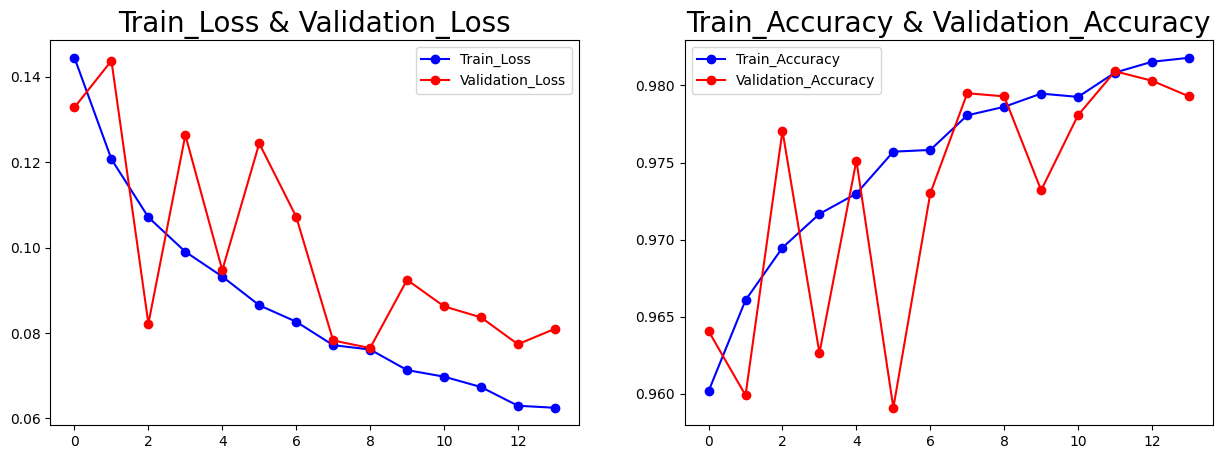

In [ ]:
plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
plt.plot(hist_['loss'],'b-o',label='Train_Loss')
plt.plot(hist_['val_loss'],'r-o',label='Validation_Loss')
plt.title('Train_Loss & Validation_Loss',fontsize=20)
plt.legend()
plt.subplot(1,2,2)
plt.plot(hist_['accuracy'],'b-o',label='Train_Accuracy')
plt.plot(hist_['val_accuracy'],'r-o',label='Validation_Accuracy')
plt.title('Train_Accuracy & Validation_Accuracy',fontsize=20)
plt.legend()

In [ ]:
# Check the shape of the input data
print("Shape of inter_x_test:", inter_x_test.shape)
print("Shape of inter_y_test:", inter_y_test.shape)

inter_x_test = inter_x_test.numpy() if isinstance(inter_x_test, tf.Tensor) else inter_x_test
inter_y_test = inter_y_test.numpy() if isinstance(inter_y_test, tf.Tensor) else inter_y_test
if not inter_x_test.shape:

    inter_x_test = inter_x_test.reshape((num_samples, *input_shape))
if not inter_y_test.shape:

    inter_y_test = inter_y_test.reshape((num_samples, *output_shape))


Shape of inter_x_test: (10934, 144)
Shape of inter_y_test: (10934,)


In [ ]:
loss, acc = model.evaluate(inter_x_test, inter_y_test, verbose=2)
print("Validation loss : {} \nAccuracy : {}".format(loss, acc))

342/342 - 2s - 7ms/step - accuracy: 0.9805 - loss: 0.0693
Validation loss : 0.069302499294281 
Accuracy : 0.9805194735527039


In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import timeit

# Assuming your model is trained and inter_x_test, inter_y_test are defined

# Measure prediction time
prediction_start = timeit.default_timer()
predictions = model.predict(inter_x_test)
prediction_end = timeit.default_timer()

print(f"Prediction duration: {prediction_end - prediction_start:.4f} seconds")

# Convert predicted probabilities to class labels
predicted_labels = np.argmax(predictions, axis=1)

conf_matrix = confusion_matrix(inter_y_test, predicted_labels, labels=[0, 1, 2, 3, 4])

# Calculate metrics manually (if needed)
print("{:^5}\t{:^10}\t{:^10}\t{:^10}\t{:^10}".format("Class", "Sensitivity", "Specificity", "PPV", "NPV"))
print(60 * "-")

for i, class_label in enumerate(['F', 'N', 'S', 'V', 'Q']):
    TP = conf_matrix[i, i]
    FN = np.sum(conf_matrix[i, :]) - TP
    FP = np.sum(conf_matrix[:, i]) - TP
    TN = np.sum(conf_matrix) - (TP + FN + FP)

    sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0
    specificity = TN / (TN + FP) if (TN + FP) > 0 else 0
    ppv = TP / (TP + FP) if (TP + FP) > 0 else 0
    npv = TN / (TN + FN) if (TN + FN) > 0 else 0

    print(f"{class_label:^5}\t{sensitivity*100:^10.2f}\t{specificity*100:^10.2f}\t{ppv*100:^10.2f}\t{npv*100:^10.2f}")

342/342 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
Prediction duration: 5.1714 seconds
Class	Sensitivity	Specificity	   PPV    	   NPV    
------------------------------------------------------------
  F  	  72.58   	  99.95   	  90.00   	  99.84   
  N  	  99.19   	  93.88   	  98.64   	  96.29   
  S  	  76.57   	  99.78   	  90.98   	  99.34   
  V  	  95.31   	  99.48   	  93.24   	  99.65   
  Q  	  98.02   	  99.90   	  98.83   	  99.83   


Confusion Matrix:
 [[  45   10    0    7    0]
 [   3 8870   22   38    9]
 [   0   62  232    8    1]
 [   2   33    1  731    0]
 [   0   17    0    0  843]]


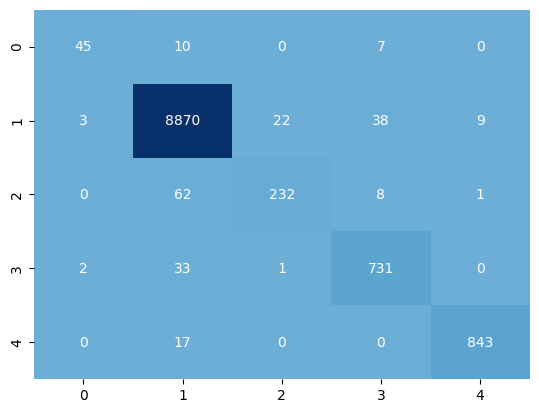

In [ ]:
# Calculate confusion matrix
conf_matrix = confusion_matrix(inter_y_test, predicted_labels, labels=[0, 1, 2, 3, 4])
sns.heatmap(conf_matrix,fmt='g',center = True,cbar=False,annot=True,cmap='Blues')
print("Confusion Matrix:\n", conf_matrix)

In [ ]:
# Print classification report
class_report = classification_report(inter_y_test, predicted_labels, target_names=['F', 'N', 'S', 'V', 'Q'])
print("\nClassification Report:\n", class_report)


Classification Report:
               precision    recall  f1-score   support

           F       0.90      0.73      0.80        62
           N       0.99      0.99      0.99      8942
           S       0.91      0.77      0.83       303
           V       0.93      0.95      0.94       767
           Q       0.99      0.98      0.98       860

    accuracy                           0.98     10934
   macro avg       0.94      0.88      0.91     10934
weighted avg       0.98      0.98      0.98     10934



In [ ]:
# Calculate overall accuracy
accuracy = accuracy_score(inter_y_test, predicted_labels)
print(f"Overall Accuracy: {accuracy:.2f}")

Overall Accuracy: 0.98
